<a href="https://colab.research.google.com/github/asegura4488/FisicaA/blob/main/Semana9/CircuitoCuadrado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

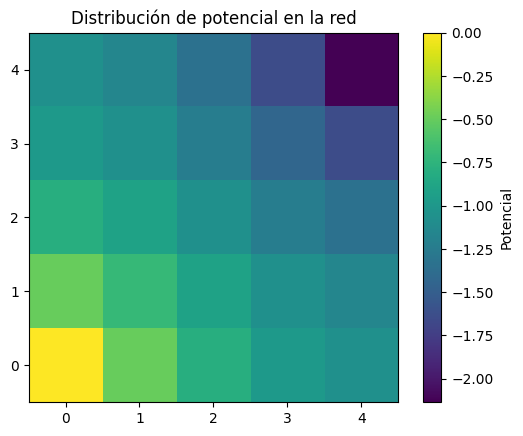

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Tamaño de la red
N = 5  # N x N nodos
num_nodos = N * N

# Función para convertir (i,j) → índice
def idx(i, j):
    return i * N + j

# Inicializar matriz L
L = np.zeros((num_nodos, num_nodos))

# Construcción del sistema
for i in range(N):
    for j in range(N):
        nodo = idx(i, j)

        vecinos = []

        if i > 0:
            vecinos.append((i-1, j))
        if i < N-1:
            vecinos.append((i+1, j))
        if j > 0:
            vecinos.append((i, j-1))
        if j < N-1:
            vecinos.append((i, j+1))

        for (vi, vj) in vecinos:
            vecino = idx(vi, vj)

            G = 1.0  # R = 1 → G = 1

            L[nodo, nodo] += G
            L[nodo, vecino] -= G

# Vector de corrientes
I = np.zeros(num_nodos)

# Fuente y sumidero
I[idx(0, 0)] = 1.0
I[idx(N-1, N-1)] = -1.0

# Fijar nodo de referencia (tierra)
L_reducida = L[1:, 1:]
I_reducida = I[1:]

# Resolver
V_reducido = np.linalg.solve(L_reducida, I_reducida)

# Reconstruir
V = np.zeros(num_nodos)
V[1:] = V_reducido

# Convertir a matriz 2D
V_grid = V.reshape((N, N))

# Visualización
plt.imshow(V_grid, origin='lower')
plt.colorbar(label="Potencial")
plt.title("Distribución de potencial en la red")
plt.show()